2026-04-09 16:18:06 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\train_test_split\train.csv
2026-04-09 16:18:07 - src.utils.file_handler - INFO - Successfully loaded 22814 rows and 22 columns
2026-04-09 16:18:07 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\train_test_split\test.csv
2026-04-09 16:18:07 - src.utils.file_handler - INFO - Successfully loaded 6519 rows and 22 columns
Training set: (22814, 21)
Test set: (6519, 21)
Training Random Forest...
Random Forest training complete!
Random Forest Accuracy: 0.9233
Random Forest ROC-AUC: 0.9785

Classification Report:
              precision    recall  f1-score   support

        Fail       0.97      0.88      0.92      3442
        Pass       0.88      0.97      0.92      3077

    accuracy                           0.92      6519
   macro avg       0.93      0.93      0.92      6519

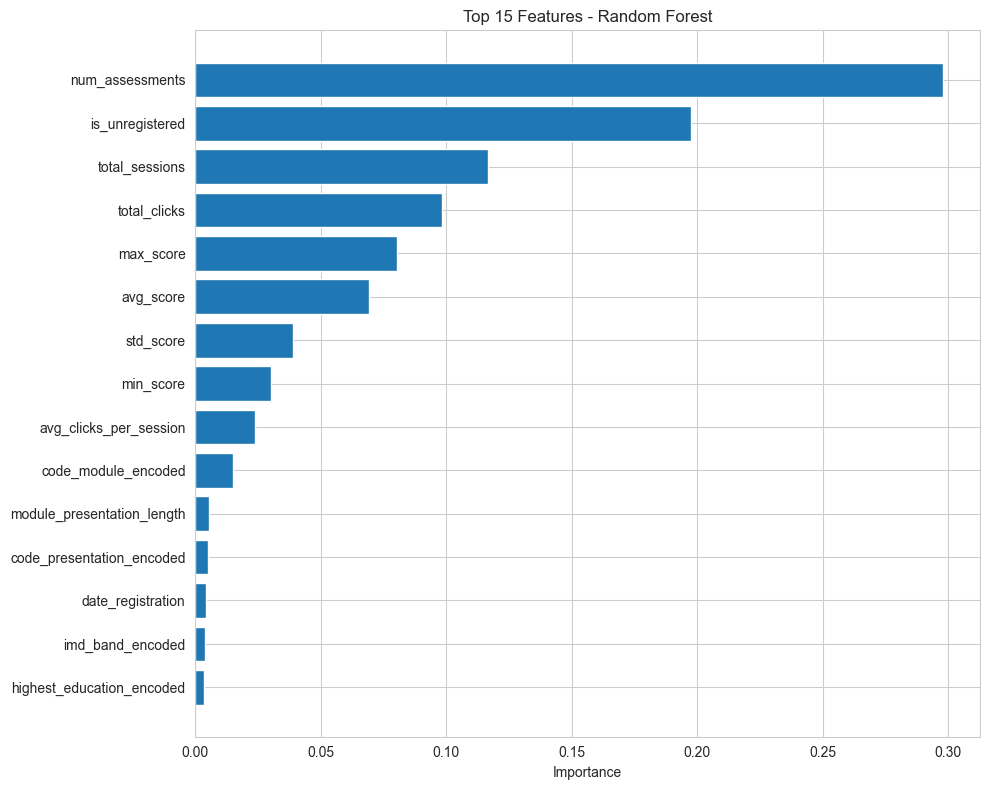

Training Gradient Boosting...
Gradient Boosting training complete!
Gradient Boosting Accuracy: 0.9337
Gradient Boosting ROC-AUC: 0.9825

Classification Report:
              precision    recall  f1-score   support

        Fail       0.96      0.92      0.94      3442
        Pass       0.91      0.95      0.93      3077

    accuracy                           0.93      6519
   macro avg       0.93      0.93      0.93      6519
weighted avg       0.93      0.93      0.93      6519



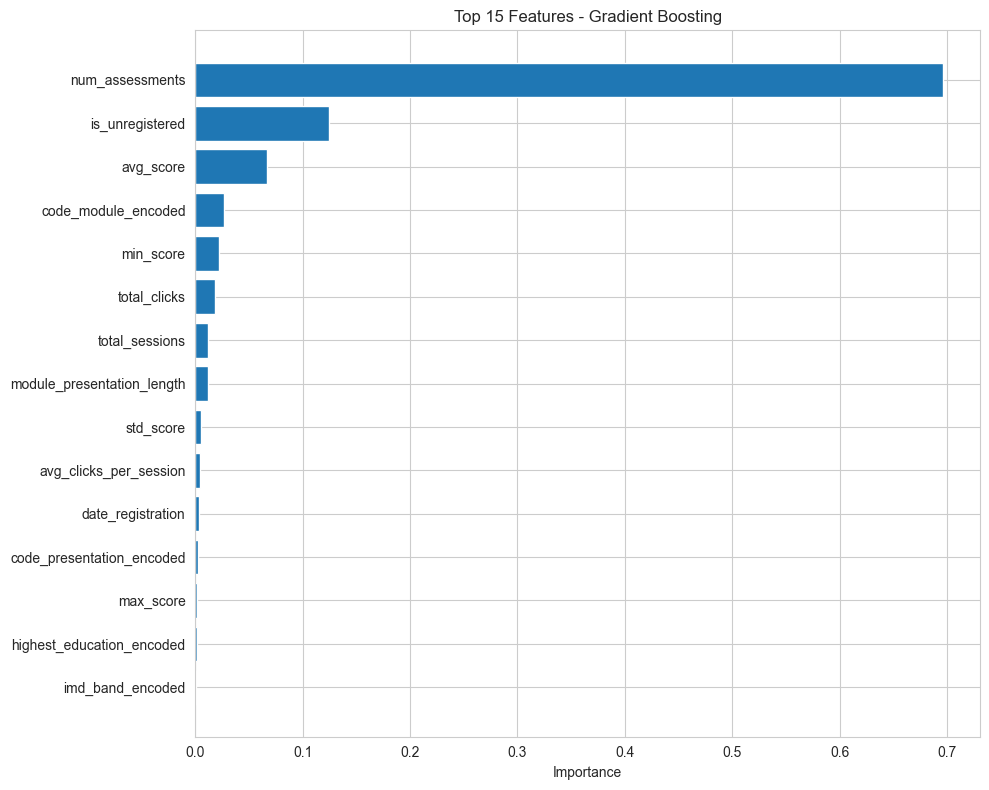


Model Comparison:
          Random Forest  Gradient Boosting
Accuracy       0.923301           0.933732
ROC-AUC        0.978546           0.982509


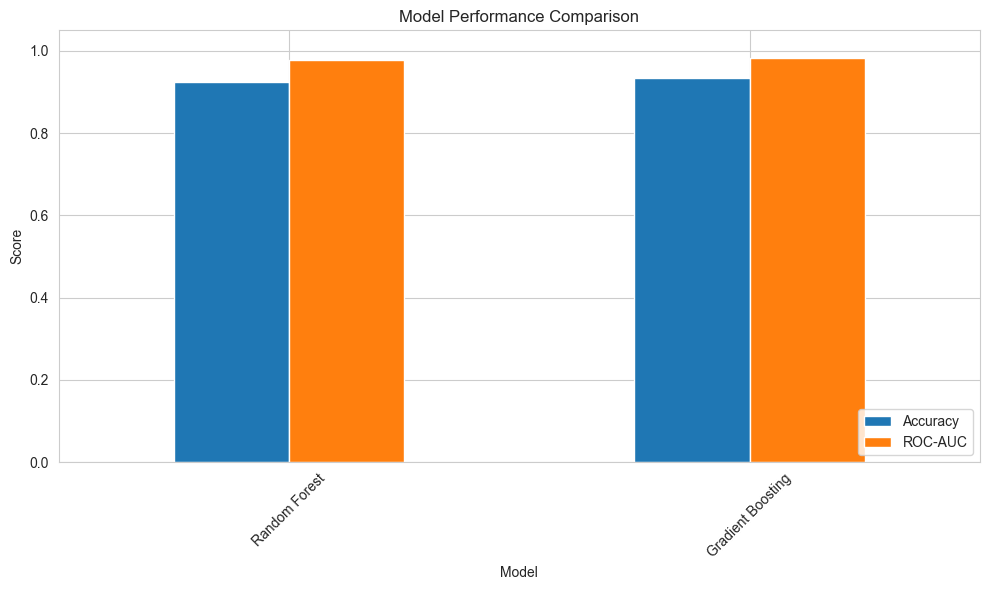

IMPROVED MODELS SUMMARY

Random Forest:
  Accuracy: 0.9233
  ROC-AUC: 0.9785

Gradient Boosting:
  Accuracy: 0.9337
  ROC-AUC: 0.9825

Best Model: Gradient Boosting


: 

In [ ]:
### notebooks/04_improved_models.ipynb
# Cell 1: Setup
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from src.config import PROCESSED_DATA_DIR
from src.utils.file_handler import load_csv

sns.set_style("whitegrid")

# Cell 2: Load Data
splits_dir = PROCESSED_DATA_DIR / "train_test_split"

train_data = load_csv(splits_dir / "train.csv")
test_data = load_csv(splits_dir / "test.csv")

X_train = train_data.drop('pass_fail', axis=1)
y_train = train_data['pass_fail']

X_test = test_data.drop('pass_fail', axis=1)
y_test = test_data['pass_fail']

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Cell 3: Train Random Forest
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=5
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete!")

# Cell 4: Random Forest Performance
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_proba_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

# Cell 5: Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_rf = rf_importance.head(15)
plt.barh(range(len(top_rf)), top_rf['importance'])
plt.yticks(range(len(top_rf)), top_rf['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Cell 6: Train Gradient Boosting
print("Training Gradient Boosting...")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42,
    learning_rate=0.1,
    max_depth=5
)

gb_model.fit(X_train, y_train)
print("Gradient Boosting training complete!")

# Cell 7: Gradient Boosting Performance
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_proba_gb)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print(f"Gradient Boosting ROC-AUC: {gb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['Fail', 'Pass']))

# Cell 8: Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_gb = gb_importance.head(15)
plt.barh(range(len(top_gb)), top_gb['importance'])
plt.yticks(range(len(top_gb)), top_gb['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features - Gradient Boosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Cell 9: Model Comparison
comparison = pd.DataFrame({
    'Random Forest': [rf_accuracy, rf_auc],
    'Gradient Boosting': [gb_accuracy, gb_auc]
}, index=['Accuracy', 'ROC-AUC'])

print("\nModel Comparison:")
print(comparison)

# Visualization
comparison.T.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

# Cell 10: Summary
print("="*60)
print("IMPROVED MODELS SUMMARY")
print("="*60)
print(f"\nRandom Forest:")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  ROC-AUC: {rf_auc:.4f}")
print(f"\nGradient Boosting:")
print(f"  Accuracy: {gb_accuracy:.4f}")
print(f"  ROC-AUC: {gb_auc:.4f}")

if rf_accuracy > gb_accuracy:
    print(f"\nBest Model: Random Forest")
else:
    print(f"\nBest Model: Gradient Boosting")